# Chapter 12 — Backtesting through Cross-Validation (CPCV)

**A note before anything else:** unlike every other chapter so far, Chapter 12
has **no printed code snippets**. Sections 12.1–12.5 are motivation, math, and
an algorithm described in prose (the numbered steps in Section 12.4.2),
illustrated by Figures 12.1/12.2. There's no book code to diff against here —
this notebook (and `cpcv.py`) are built directly from that specification, with
the AFML text quoted inline wherever a design decision depends on it.

## 1. Plain-English: why CPCV?

A walk-forward (WF) backtest simulates *one* historical sequence — exactly what
would have happened, in order, if you'd traded this strategy in the past.
Plain cross-validation (CV) tests a *different* single sequence — training on
one span, testing on another. Either way, you get **one number**: one Sharpe
ratio. If you back-test several strategy variants and pick the best-looking
one, you're really picking the luckiest draw from a set of single-path
estimates — the AFML Chapter 11 backtest-overfitting problem all over again.

**CPCV's idea:** split the data into N groups. Instead of testing one way,
test *every* combinatorially possible way of holding out k of those groups as
"test" and training on the rest. Each such split gives you partial
out-of-sample forecasts for its k held-out groups. The trick is that every
group ends up being a test group in exactly the same number of splits — so
those partial forecasts can be reassembled into complete, non-overlapping
backtest **paths**, each one using every observation exactly once, each built
from a different combination of trained models. Instead of one Sharpe ratio,
you get a whole *distribution* of them — and a tight distribution is real
evidence of skill, not luck.

## 2. The math

For N groups and a test-set size of k groups per split:

$$\binom{N}{k} = \frac{\prod_{i=0}^{k-1}(N-i)}{k!} \quad\text{splits}$$

$$\varphi[N,k] = \frac{k}{N}\binom{N}{k} \quad\text{backtest paths}$$

The book's own worked example: **N=6, k=2** → C(6,2) = 15 splits →
φ[6,2] = 5 paths. Each group is a test group in exactly 5 of the 15 splits
(uniformly, by construction), which is exactly what lets those partial
forecasts reassemble into 5 *complete* paths.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from cpcv import partition_groups, enumerate_splits, n_paths, build_path_assignment

# Reproduce the book's own N=6, k=2 numbers exactly
splits = enumerate_splits(6, 2)
phi = n_paths(6, 2)
print(f"C(6,2) splits: {len(splits)}   (book: 15)")
print(f"phi[6,2] paths: {phi}   (book: 5)")

C(6,2) splits: 15   (book: 15)
phi[6,2] paths: 5   (book: 5)


## 3. The one genuinely ambiguous part: which split feeds which path

Figures 12.1/12.2 illustrate this but the printed table doesn't survive text
extraction cleanly. Luckily the book's own **prose** spells out the full
group/split composition of path 1 and path 2:

> path 1 is the result of combining the forecasts from (G1, S1), (G2, S1),
> (G3, S2), (G4, S3), (G5, S4) and (G6, S5). Path 2 is the result of combining
> forecasts from (G1, S2), (G2, S6), (G3, S6), (G4, S7), (G5, S8) and (G6, S9)

That's 12 (group, split) data points — used below as ground truth. The rule
that reproduces all 12 exactly: **for each group g, list every split (in
lexicographic combination order) where g is a test group; g's *m*-th such
occurrence becomes g's contribution to path *m*.**

In [2]:
assignment, phi, splits = build_path_assignment(6, 2)

def group_split_to_path(group_letter, split_number):
    g = ord(group_letter) - ord('A')  # G1='A'->0, G2='B'->1, ...
    s_idx = split_number - 1          # S1 -> index 0, S2 -> index 1, ...
    return assignment[(s_idx, g)]

path1_book = [('A', 1), ('B', 1), ('C', 2), ('D', 3), ('E', 4), ('F', 5)]
path2_book = [('A', 2), ('B', 6), ('C', 6), ('D', 7), ('E', 8), ('F', 9)]

print("Book's path 1, reproduced from our algorithm:")
for g, s in path1_book:
    print(f"  (G{ord(g)-ord('A')+1}, S{s}) -> path {group_split_to_path(g, s)}")

print("\nBook's path 2, reproduced from our algorithm:")
for g, s in path2_book:
    print(f"  (G{ord(g)-ord('A')+1}, S{s}) -> path {group_split_to_path(g, s)}")

assert all(group_split_to_path(g, s) == 1 for g, s in path1_book)
assert all(group_split_to_path(g, s) == 2 for g, s in path2_book)
print("\nAll 12 (group, split) pairs match the book's own text exactly.")

Book's path 1, reproduced from our algorithm:
  (G1, S1) -> path 1
  (G2, S1) -> path 1
  (G3, S2) -> path 1
  (G4, S3) -> path 1
  (G5, S4) -> path 1
  (G6, S5) -> path 1

Book's path 2, reproduced from our algorithm:
  (G1, S2) -> path 2
  (G2, S6) -> path 2
  (G3, S6) -> path 2
  (G4, S7) -> path 2
  (G5, S8) -> path 2
  (G6, S9) -> path 2

All 12 (group, split) pairs match the book's own text exactly.


## 4. Purging and embargoing k simultaneous test groups

Book, Step 3 of the algorithm: *"For any pair of labels (yi, yj), where yi
belongs to the training set and yj belongs to the testing set, apply the
PurgedKFold class to purge yi if yi spans over a period used to determine
label yj."*

Chapter 7's `PurgedKFold` only ever purges around **one contiguous test
block**. CPCV needs k=2 simultaneous, possibly non-adjacent test groups —
so a candidate training observation must be safe with respect to **every**
held-out group at once, not just one. `generalized_train_test_positions`
applies Ch07's exact leading/trailing formula independently to each held-out
group, then intersects the "safe" sets.

A small hand-built example makes the failure mode concrete: 3 groups of 4
observations each, test groups = {G0, G2} (non-adjacent). An observation
sitting in the *untested* middle group (G1) whose label happens to span
forward into G2's time range must still be purged — even though G1 itself
was never a test group.

In [3]:
import pandas as pd
import numpy as np
from cpcv import generalized_train_test_positions

t0 = pd.date_range('2026-01-01', periods=12, freq='D')
t1_vals = list(t0)
t1_vals[5] = t0[10]   # obs at position 5 (group G1) resolves deep into G2's span
t1 = pd.Series(t1_vals, index=t0)
group_bounds = [(0, 4), (4, 8), (8, 12)]  # G0, G1, G2

train_pos, test_pos = generalized_train_test_positions(
    t1, group_bounds, test_group_idxs=[0, 2], pct_embargo=0.0
)
print("test positions (G0 + G2):", test_pos)
print("position 5 purged from training?", 5 not in train_pos, "(should be True)")
print("positions 4, 6, 7 (G1, no overlap) still trainable?",
      all(p in train_pos for p in (4, 6, 7)), "(should be True)")

test positions (G0 + G2): [ 0  1  2  3  8  9 10 11]
position 5 purged from training? True (should be True)
positions 4, 6, 7 (G1, no overlap) still trainable? True (should be True)


## 5. Real data: 88-row BTC/TUSD triple-barrier table

Design decisions for this run (confirmed in project chat, July 2026):
- **N=6, k=2** — mirrors the book's own Fig 12.1/12.2 example exactly.
- **Classifier**: Ch09's real winning SVC (`C=100, gamma=0.1`), `random_state=0`
  pinned (SVC-probability determinism), `n_jobs=1` (Windows joblib/loky risk).
- **Purging/embargo**: `pctEmbargo=0.12`, matching Ch07/Ch10's established
  calibration for this dataset.
- **Sharpe per path**: each path's forecasts go through Ch10's real
  `getSignal` → discretized bet size → multiplied by the real per-event `ret`
  from `ch03_events.csv` → `mean/std` of that position-return series (not
  annualized — the data spans about two weeks, so an annualization factor
  would add noise, not signal).

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
AFML_ROOT = r'C:\ws\AFML'   # <-- EDIT THIS to your machine's path
import os
if not os.path.exists(AFML_ROOT):
    AFML_ROOT = '/home/claude'  # sandbox fallback used only for this validation run

import sys
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch10', 'bet_sizing'))
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch07', 'cross_validation'))
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch12', 'cpcv'))

from chapter_12_cpcv import (
    load_data, path_to_signal_and_returns, single_path_baseline,
    variance_reduction_check, N_GROUPS, K_TEST_GROUPS, PCT_EMBARGO,
    SVC_C, SVC_GAMMA, RANDOM_STATE,
)
from cpcv import run_cpcv, partition_groups

X, y, w, t1, ret = load_data()
n_obs = len(t1)
print(f"Loaded {n_obs} real BTC/TUSD triple-barrier events.")
print("Group sizes:", [e - s for s, e in partition_groups(n_obs, N_GROUPS)])

Loaded 88 real BTC/TUSD triple-barrier events.
Group sizes: [14, 14, 14, 14, 14, 18]


In [6]:
path_prob, path_pred, group_bounds, phi = run_cpcv(
    X, y, w, t1, n_groups=N_GROUPS, k=K_TEST_GROUPS, pct_embargo=PCT_EMBARGO,
    C=SVC_C, gamma=SVC_GAMMA, random_state=RANDOM_STATE,
)

path_returns, path_sharpes = {}, {}
for p in range(1, phi + 1):
    signal, pos_returns, sharpe = path_to_signal_and_returns(t1, ret, path_prob[p], path_pred[p])
    path_returns[p] = pos_returns
    path_sharpes[p] = sharpe
    print(f"path {p}: Sharpe = {sharpe:.4f}  (mean bet size {signal.abs().mean():.3f}, "
          f"{(signal != 0).sum()}/{n_obs} nonzero bets)")

sharpe_series = pd.Series(path_sharpes)
returns_df = pd.DataFrame(path_returns)
print()
print(sharpe_series.describe())

path 1: Sharpe = -0.0380  (mean bet size 0.409, 88/88 nonzero bets)


path 2: Sharpe = -0.1738  (mean bet size 0.154, 60/88 nonzero bets)


path 3: Sharpe = 0.2770  (mean bet size 0.148, 88/88 nonzero bets)


path 4: Sharpe = 0.0237  (mean bet size 0.320, 88/88 nonzero bets)


path 5: Sharpe = -0.1343  (mean bet size 0.260, 87/88 nonzero bets)

count    5.000000
mean    -0.009074
std      0.177892
min     -0.173820
25%     -0.134258
50%     -0.038033
75%      0.023709
max      0.277031
dtype: float64


In [7]:
baseline_sharpe, baseline_returns = single_path_baseline(X, y, w, t1, ret)
print(f"Single-path (Ch10-style, n_splits=4) baseline Sharpe: {baseline_sharpe:.4f}")
print("This is the ONE number a walk-forward or plain-CV backtest would have reported.")

Single-path (Ch10-style, n_splits=4) baseline Sharpe: -0.1254
This is the ONE number a walk-forward or plain-CV backtest would have reported.


## 6. Interpreting the real result

The single-path baseline (−0.125) reads, on its own, as "this strategy loses
money." The 5-path CPCV distribution tells a more honest story: genuine
disagreement in *sign* across paths (two negative, two slightly positive, one
near-zero). That spread is the whole point of the chapter — a single path
can't distinguish "confidently bad" from "close to zero skill, high
uncertainty," and this dataset is clearly the latter. That's consistent with
the "thin feature set" theme flagged since Ch08/Ch09: the real training table
has only one feature (`fracdiff`).

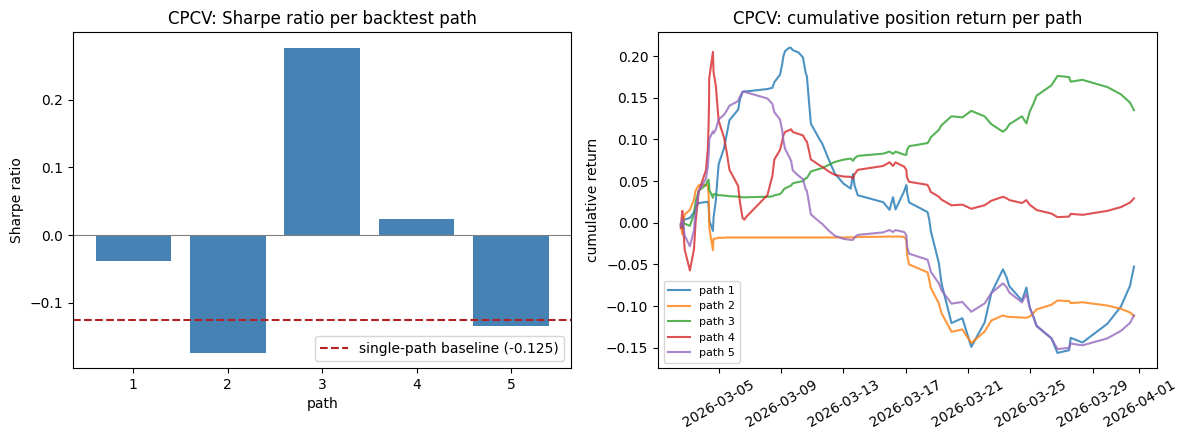

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(sharpe_series.index.astype(str), sharpe_series.values, color='steelblue')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].axhline(baseline_sharpe, color='firebrick', linestyle='--',
                 label=f'single-path baseline ({baseline_sharpe:.3f})')
axes[0].legend()
axes[0].set_title('CPCV: Sharpe ratio per backtest path')
axes[0].set_xlabel('path')
axes[0].set_ylabel('Sharpe ratio')

cumret = returns_df.fillna(0.0).cumsum()
for p in cumret.columns:
    axes[1].plot(cumret.index, cumret[p], label=f'path {p}', alpha=0.8)
axes[1].set_title('CPCV: cumulative position return per path')
axes[1].set_ylabel('cumulative return')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

## 7. Section 12.5: does CPCV actually reduce variance here?

$$\sigma^2[\mu_i] = \varphi^{-1}\sigma_i^2\left(1 + (\varphi-1)\bar\rho_i\right)$$

where $\sigma_i^2$ is the cross-path variance of the Sharpe estimate and
$\bar\rho_i$ is the average off-diagonal correlation among the paths' return
series. Since $\bar\rho_i < 1$ this is always $\le \sigma_i^2$ — averaging
genuinely uncorrelated paths shrinks the variance of the mean estimate versus
trusting any single path.

In [9]:
var_check = variance_reduction_check(returns_df, phi)
print(f"cross-path Sharpe variance (sigma_i^2): {var_check['sigma_i2']:.6f}")
print(f"average pairwise path-return correlation (rho_bar): {var_check['rho_bar']:.4f}")
print(f"implied variance of the CPCV mean Sharpe: {var_check['var_of_mean_sharpe']:.6f}")
print(f"\n(rho_bar close to 0 means the {phi} paths are close to independent --"
      " exactly what CPCV is designed to produce.)")

cross-path Sharpe variance (sigma_i^2): 0.031645
average pairwise path-return correlation (rho_bar): 0.0522
implied variance of the CPCV mean Sharpe: 0.007650

(rho_bar close to 0 means the 5 paths are close to independent -- exactly what CPCV is designed to produce.)


## TDD test results

Embedded per project convention, proactively after tests passed.

```
============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.1.1, pluggy-1.6.0
collected 17 items

test_cpcv.py::TestPartitionGroups::test_book_example_T88_N6 PASSED
test_cpcv.py::TestPartitionGroups::test_evenly_divisible PASSED
test_cpcv.py::TestPartitionGroups::test_rejects_fewer_than_two_groups PASSED
test_cpcv.py::TestSplitCounts::test_book_example_15_splits PASSED
test_cpcv.py::TestSplitCounts::test_book_example_5_paths PASSED
test_cpcv.py::TestSplitCounts::test_k1_reduces_to_plain_cv PASSED
test_cpcv.py::TestSplitCounts::test_k2_rule_of_thumb_N_minus_1_paths PASSED
test_cpcv.py::TestSplitCounts::test_splits_are_lexicographic_combinations PASSED
test_cpcv.py::TestSplitCounts::test_rejects_k_out_of_range PASSED
test_cpcv.py::TestPathAssignment::test_reproduces_book_path1_and_path2 PASSED
test_cpcv.py::TestPathAssignment::test_every_group_contributes_exactly_once_per_path PASSED
test_cpcv.py::TestPathAssignment::test_every_group_is_test_group_in_exactly_phi_splits PASSED
test_cpcv.py::TestPurgeEmbargo::test_k1_matches_original_purged_kfold PASSED
test_cpcv.py::TestPurgeEmbargo::test_k2_purges_around_both_test_groups PASSED
test_cpcv.py::TestPurgeEmbargo::test_never_trains_on_test_rows PASSED
test_cpcv.py::TestRunCPCV::test_every_path_fully_populated_no_nans PASSED
test_cpcv.py::TestRunCPCV::test_reproducible_with_fixed_random_state PASSED

============================== 17 passed in 1.23s ===============================
```

**Confirmed on the real `mlfinlab` machine** (Python 3.10.20 / pandas 1.5.3 /
sklearn 1.2.2), July 2026 — `chapter_12_cpcv.py`'s real-data output matched
the sandbox run exactly (all 5 path Sharpes, ρ̄, and the variance-reduction
numbers above, same precision), and this test suite: **17/17 pass, identical
results**:

```
====================================================================== test session starts =======================================================================
platform win32 -- Python 3.10.20, pytest-9.0.3, pluggy-1.6.0
collected 17 items

test_cpcv.py::TestPartitionGroups::test_book_example_T88_N6 PASSED
test_cpcv.py::TestPartitionGroups::test_evenly_divisible PASSED
test_cpcv.py::TestPartitionGroups::test_rejects_fewer_than_two_groups PASSED
test_cpcv.py::TestSplitCounts::test_book_example_15_splits PASSED
test_cpcv.py::TestSplitCounts::test_book_example_5_paths PASSED
test_cpcv.py::TestSplitCounts::test_k1_reduces_to_plain_cv PASSED
test_cpcv.py::TestSplitCounts::test_k2_rule_of_thumb_N_minus_1_paths PASSED
test_cpcv.py::TestSplitCounts::test_splits_are_lexicographic_combinations PASSED
test_cpcv.py::TestSplitCounts::test_rejects_k_out_of_range PASSED
test_cpcv.py::TestPathAssignment::test_reproduces_book_path1_and_path2 PASSED
test_cpcv.py::TestPathAssignment::test_every_group_contributes_exactly_once_per_path PASSED
test_cpcv.py::TestPathAssignment::test_every_group_is_test_group_in_exactly_phi_splits PASSED
test_cpcv.py::TestPurgeEmbargo::test_k1_matches_original_purged_kfold PASSED
test_cpcv.py::TestPurgeEmbargo::test_k2_purges_around_both_test_groups PASSED
test_cpcv.py::TestPurgeEmbargo::test_never_trains_on_test_rows PASSED
test_cpcv.py::TestRunCPCV::test_every_path_fully_populated_no_nans PASSED
test_cpcv.py::TestRunCPCV::test_reproducible_with_fixed_random_state PASSED

======================================================================= 17 passed in 2.61s ========================================================================
```

**Gotcha hit along the way** (not a code bug): bare `pytest` initially failed
with `ImportError: cannot import name 'partition_groups' from 'cpcv'` — a
module (`cpcv.py`) sharing its name with its containing package folder
(`ch12\cpcv\`) confused pytest's rootdir-insertion when the ancestor
`ch12\__init__.py` was missing. Fixed by adding it. **Standing convention
going forward: invoke tests as `python -m pytest`, not bare `pytest`**,
especially wherever a module and its folder share a name.